## Бинарная классификация

Загружено 50 признаков из RFECV
Загружено 16639 строк данных
Train size: (13308, 50), Test size: (3331, 50)
Class distribution in test: 0=477, 1=2854


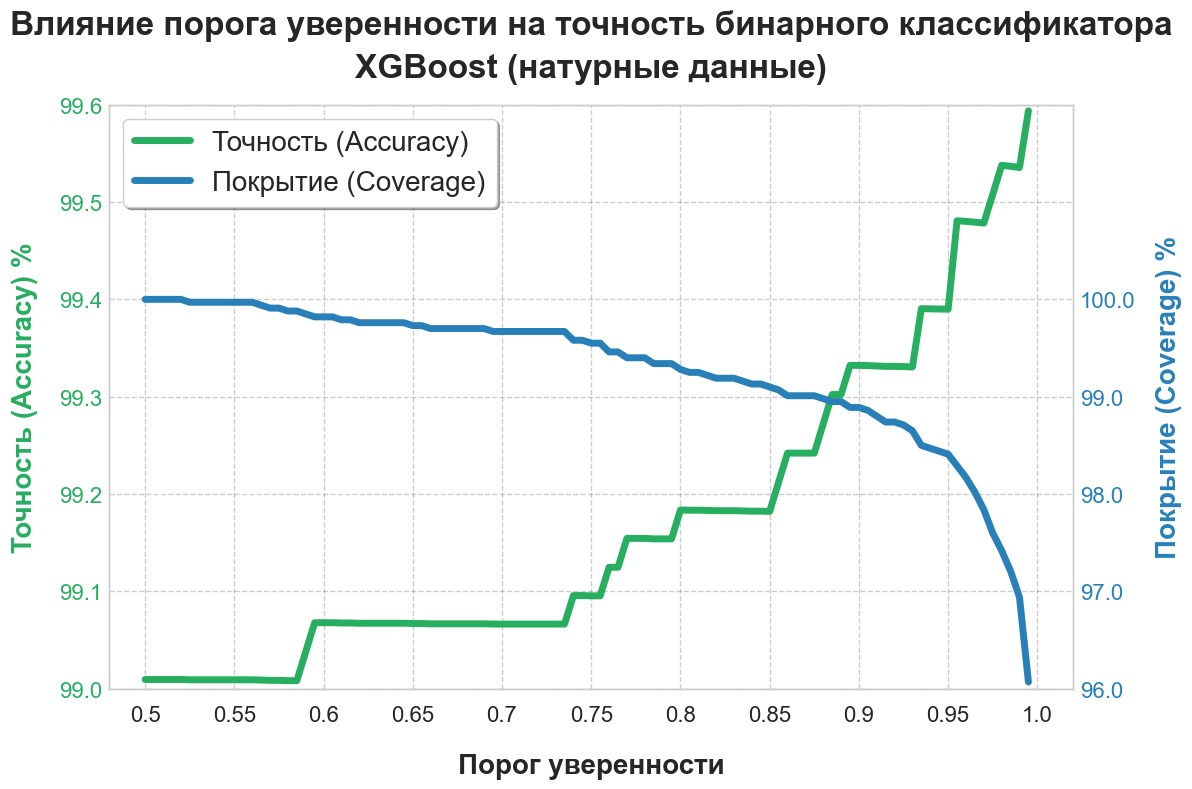


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 99.01%, Coverage = 100.0%
При пороге 0.950: Accuracy = 99.39%, Coverage = 98.4%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.59%, Coverage=96.1%


In [2]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score
import os
import json

# 1. Функция хронологического разделения (80/20)
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
file_path = "DATA/features/REAL_features_ws32_overlap75.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
print(f"Загружено {len(features)} признаков из RFECV")

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")
    
    X_train, X_test, y_train, y_test = prepare_data(df, binary=True, chronological=True, selected_features=features)
    
    print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
    print(f"Class distribution in test: 0={sum(y_test==0)}, 1={sum(y_test==1)}")

    # Обучение модели
    model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
    model.fit(X_train, y_train)

    # 3. Анализ порогов уверенности (Reject Option)
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) # Максимальная вероятность из двух классов
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.5, 0.995, 100)
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # ========== НАСТРОЙКИ ОТСТУПОВ ==========
    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность бинарного классификатора\nXGBoost (натурные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

    x_min, x_max = 0.48, 1.02
    
    # Настройка оси X
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(0.5, 1.05, 0.05)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    # === СИНХРОНИЗАЦИЯ ОСЕЙ С ОТКЛЮЧЕНИЕМ ВЕРХНИХ ДВУХ ДЕЛЕНИЙ ===
    acc_min, acc_max = 99, 99.6
    cov_min, cov_max = 96, 102

    n_ticks = 7  # Всего 7 делений
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Деления для левой оси (все 7)
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks], fontsize=16)
    
    # Для правой оси: вычисляем все 7 делений
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    # Оставляем только первые 5 делений (скрываем последние 2)
    n_display_ticks = n_ticks - 2  # 5 делений
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    # Устанавливаем тики и метки на правой оси
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    # Сетка
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    # Легенда
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('APPLICATIONS/binary_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    # Вывод контрольных точек
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    # Поиск ближайшего порога к 0.95
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    # Лучший компромисс (максимальная точность при покрытии > 50%)
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

## НЕбинарная

Загружено 50 признаков из RFECV
Загружено 16639 строк данных
97.11538461538461


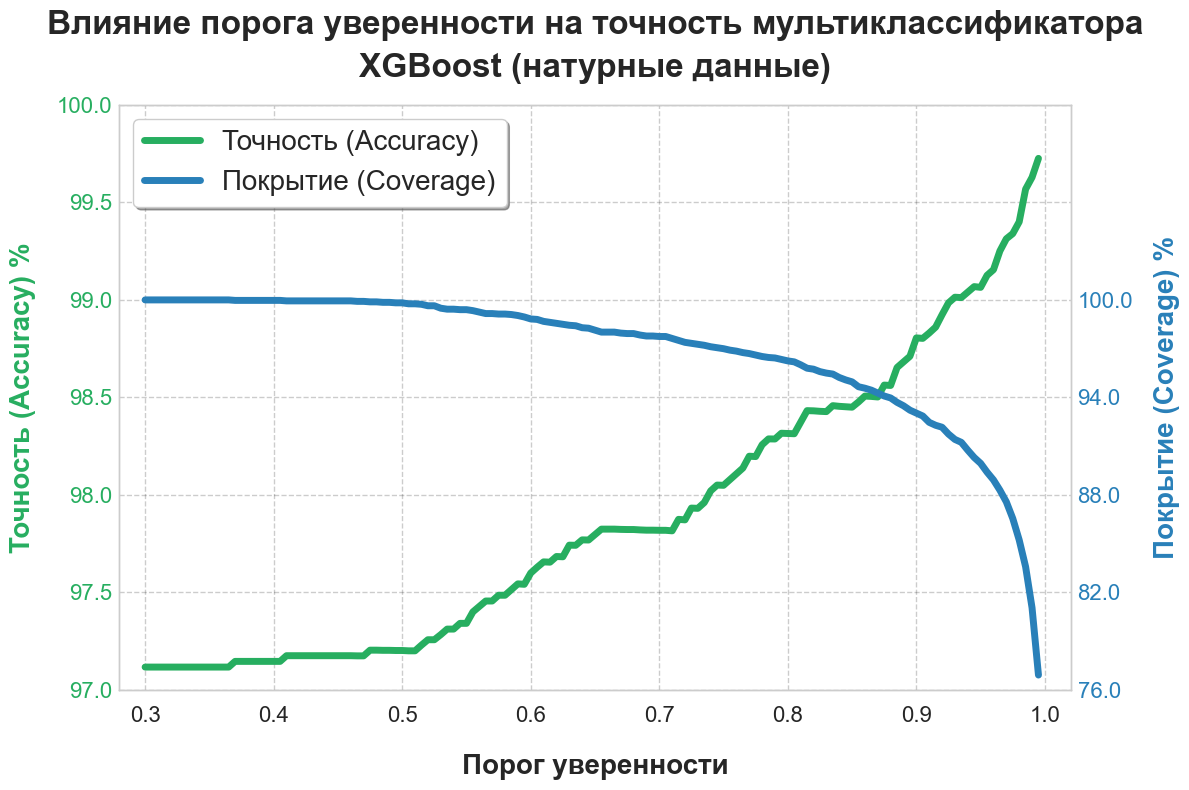


Результаты при разных порогах:
При пороге 0.50 (без фильтрации): Accuracy = 97.12%, Coverage = 100.0%
При пороге 0.950: Accuracy = 99.06%, Coverage = 89.9%
Лучший компромисс (Coverage > 50%): порог=0.995, Accuracy=99.73%, Coverage=76.9%


In [3]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier  # <--- ДОБАВИТЬ ЭТУ СТРОКУ
from sklearn.metrics import accuracy_score
import os
import json
from sklearn.model_selection import train_test_split

# 1. Функция хронологического разделения (80/20)
def prepare_data(features_df, binary=True, chronological=False, selected_features=None, test_size=0.2, scaler_type=None, random_state=42):

    if chronological:
        train_dfs = []
        test_dfs = []
    
        for class_id in sorted(features_df["Класс"].unique()):
            class_data = features_df[features_df["Класс"] == class_id]
            split_idx = int(len(class_data) * (1 - test_size))
    
            train_dfs.append(class_data.iloc[:split_idx])
            test_dfs.append(class_data.iloc[split_idx:])
    
        train_df = pd.concat(train_dfs).reset_index(drop=True)
        test_df = pd.concat(test_dfs).reset_index(drop=True)
    
        X_train = train_df.drop(columns=["Класс"])
        y_train = train_df["Класс"].values
    
        X_test = test_df.drop(columns=["Класс"])
        y_test = test_df["Класс"].values

    else:
        X = features_df.drop(columns=["Класс"])
        y = features_df["Класс"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if selected_features is not None:
        selected_features = [f for f in selected_features if f in X_train.columns]
        X_train = X_train[selected_features]
        X_test = X_test[selected_features]

    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)

    if scaler_type == "standard":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

# 2. Основной блок выполнения
file_path = "DATA/features/REAL_features_ws32_overlap75.csv" 

# ЗАГРУЗКА ПРИЗНАКОВ ИЗ RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
print(f"Загружено {len(features)} признаков из RFECV")
accuracy = 0
random_state = 1
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Загружено {len(df)} строк данных")

    while accuracy <= 97:
        X_train, X_test, y_train, y_test = prepare_data(df, binary=False, chronological=False, selected_features=features, random_state=random_state)
    
    
        # Обучение модели
        model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred) * 100
        random_state += 1
        print(accuracy)

    # 3. Анализ порогов уверенности (Reject Option)
    probs = model.predict_proba(X_test)
    confidences = np.max(probs, axis=1) # Максимальная вероятность из двух классов
    base_preds = np.argmax(probs, axis=1)

    thresholds = np.linspace(0.3, 0.995, 140)
    results = []

    for t in thresholds:
        # Маска для тех предсказаний, где модель "уверена"
        mask = confidences >= t
        
        coverage = np.mean(mask) * 100 # Процент данных, которые модель не "отбросила"
        
        if np.any(mask):
            acc = accuracy_score(y_test[mask], base_preds[mask]) * 100
        else:
            acc = None # Если модель не уверена ни в чем
            
        results.append({
            "Threshold": t,
            "Accuracy": acc,
            "Coverage": coverage
        })

    df_res = pd.DataFrame(results).dropna()

    # 4. Визуализация компромисса Точность / Покрытие
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # ========== НАСТРОЙКИ ОТСТУПОВ ==========
    ax1.xaxis.labelpad = 15
    ax1.yaxis.labelpad = 15
    
    plt.title('Влияние порога уверенности на точность мультиклассификатора\nXGBoost (натурные данные)', 
              fontsize=24, fontweight='bold', pad=20, linespacing=1.5)
    
    # Ось для Точности (левая)
    color_acc = '#27ae60'
    ax1.set_xlabel('Порог уверенности', fontsize=20, fontweight='bold', labelpad=20)
    ax1.set_ylabel('Точность (Accuracy) %', color=color_acc, fontsize=20, fontweight='bold')
    line1 = ax1.plot(df_res["Threshold"], df_res["Accuracy"], color=color_acc, linewidth=5, label='Точность (Accuracy)')
    ax1.tick_params(axis='y', labelcolor=color_acc, labelsize=12, pad=5)
    
    # Ось для Покрытия (правая)
    ax2 = ax1.twinx()
    ax2.yaxis.labelpad = 15
    
    color_cov = '#2980b9'
    ax2.set_ylabel('Покрытие (Coverage) %', color=color_cov, fontsize=20, fontweight='bold')
    line2 = ax2.plot(df_res["Threshold"], df_res["Coverage"], color=color_cov, linewidth=5, linestyle='-', label='Покрытие (Coverage)')
    ax2.tick_params(axis='y', labelcolor=color_cov, labelsize=12, pad=5)

    x_min, x_max = 0.28, 1.02
    
    # Настройка оси X
    ax1.set_xlim(x_min, x_max)
    x_ticks = np.arange(0.3, 1.05, 0.1)
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels([round(x, 2) for x in x_ticks], fontsize=16)
    ax1.tick_params(axis='x', pad=12)
    
    # === СИНХРОНИЗАЦИЯ ОСЕЙ С ОТКЛЮЧЕНИЕМ ВЕРХНИХ ДВУХ ДЕЛЕНИЙ ===
    acc_min, acc_max = 97, 100
    cov_min, cov_max = 76, 112

    n_ticks = 7  # Всего 7 делений
    
    ax1.set_ylim(acc_min, acc_max)
    ax2.set_ylim(cov_min, cov_max)
    
    # Деления для левой оси (все 7)
    acc_ticks = np.linspace(acc_min, acc_max, n_ticks)
    ax1.set_yticks(acc_ticks)
    ax1.set_yticklabels([round(x, 2) for x in acc_ticks], fontsize=16)
    
    # Для правой оси: вычисляем все 7 делений
    k = (cov_max - cov_min) / (acc_max - acc_min)
    b = cov_min - k * acc_min
    cov_ticks_all = k * acc_ticks + b
    
    # Оставляем только первые 5 делений (скрываем последние 2)
    n_display_ticks = n_ticks - 2  # 5 делений
    cov_ticks_display = cov_ticks_all[:n_display_ticks]
    cov_labels = [round(x, 2) for x in cov_ticks_display]
    
    # Устанавливаем тики и метки на правой оси
    ax2.set_yticks(cov_ticks_display)
    ax2.set_yticklabels(cov_labels, fontsize=16)
    
    # Сетка
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=1, color='black')
    ax2.grid(False)
    
    # Легенда
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=20, frameon=True, shadow=True)

    plt.tight_layout()
    plt.savefig('APPLICATIONS/multi_confidence_tradeoff_xgb_50features.png', dpi=600)
    plt.show()
    # Вывод контрольных точек
    print(f"\nРезультаты при разных порогах:")
    print(f"При пороге 0.50 (без фильтрации): Accuracy = {df_res.iloc[0]['Accuracy']:.2f}%, Coverage = {df_res.iloc[0]['Coverage']:.1f}%")
    
    # Поиск ближайшего порога к 0.95
    idx_95 = (df_res['Threshold'] - 0.95).abs().idxmin()
    print(f"При пороге {df_res.iloc[idx_95]['Threshold']:.3f}: Accuracy = {df_res.iloc[idx_95]['Accuracy']:.2f}%, Coverage = {df_res.iloc[idx_95]['Coverage']:.1f}%")
    
    # Лучший компромисс (максимальная точность при покрытии > 50%)
    high_acc = df_res[df_res['Coverage'] > 50].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"Лучший компромисс (Coverage > 50%): порог={high_acc['Threshold']:.3f}, Accuracy={high_acc['Accuracy']:.2f}%, Coverage={high_acc['Coverage']:.1f}%")

else:
    print(f"Файл данных не найден: {file_path}")
    print("Проверьте путь к CSV файлу.")

## Буфер окон


In [98]:
# 50 признаков

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
import json

# 1. Подготовка данных (Хронологический сплит)
def prepare_data_chronological(df, test_size=0.2, binary=True):
    train_dfs, test_dfs = [], []
    for class_id in sorted(df["Класс"].unique()):
        class_data = df[df["Класс"] == class_id]
        split_idx = int(len(class_data) * (1 - test_size))
        train_dfs.append(class_data.iloc[:split_idx])
        test_dfs.append(class_data.iloc[split_idx:])
    
    train_df = pd.concat(train_dfs).reset_index(drop=True)
    test_df = pd.concat(test_dfs).reset_index(drop=True)
    
    X_train = train_df.drop(columns=["Класс"])
    X_test = test_df.drop(columns=["Класс"])
    y_train = train_df["Класс"].values
    y_test = test_df["Класс"].values
    
    if binary:
        y_train = (y_train != 0).astype(int)
        y_test = (y_test != 0).astype(int)
    return X_train, X_test, y_train, y_test

# 2. Функция мажоритарного голосования в скользящем окне
def apply_rolling_predictions(y_pred, window_size=5):
    smoothed_preds = []
    for i in range(len(y_pred)):
        start_idx = max(0, i - window_size + 1)
        buffer = y_pred[start_idx : i + 1]
        final_vote = 1 if np.mean(buffer) > 0.5 else 0
        smoothed_preds.append(final_vote)
    return np.array(smoothed_preds)

file_path = "DATA/features/REAL_features_ws32_overlap96.875.csv" #96.875
df = pd.read_csv(file_path)

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]

df_filtered = df[features + ["Класс"]]
X_train, X_test, y_train, y_test = prepare_data_chronological(df_filtered)

# Обучение модели
model = XGBClassifier(device="cuda", tree_method="hist", n_jobs=-1, max_depth=7, random_state=42)
model.fit(X_train, y_train)

# Получаем базовые предсказания
y_pred_raw = model.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred_raw) * 100


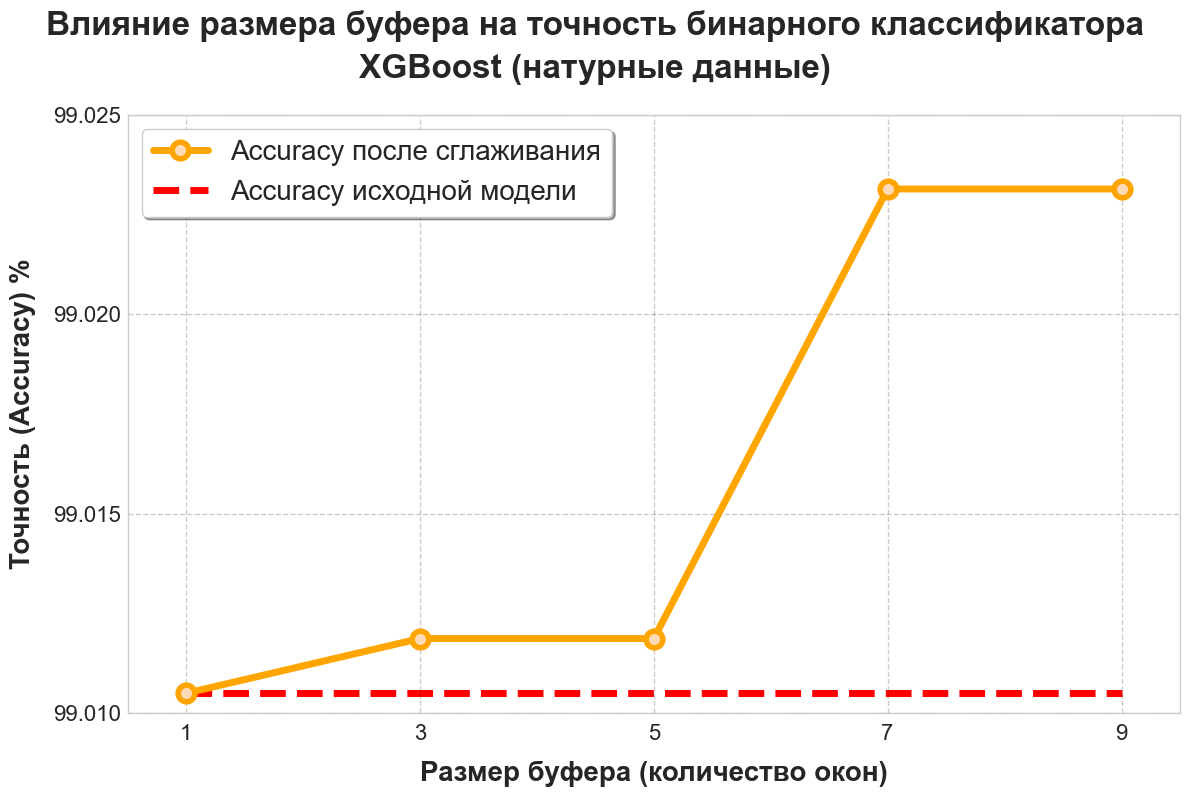

Сырая точность модели: 98.99%
Буфер 1 окон: Accuracy = 99.01%
Буфер 3 окон: Accuracy = 99.01%
Буфер 5 окон: Accuracy = 99.01%
Буфер 7 окон: Accuracy = 99.02%
Буфер 9 окон: Accuracy = 99.02%


In [119]:
# Тестируем разные размеры буфера сглаживания
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results[0]['Accuracy'] = 99.0105
df_smooth = pd.DataFrame(smoothing_results)

fig, ax = plt.subplots(figsize=(12, 8))



ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)
# ========== НАСТРОЙКА ОСЕЙ ==========

# Явно задаем позиции делений и метки для оси X
x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)


ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')

# Отступы для меток
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

# Настройка подписей и заголовка
fig.suptitle('Влияние размера буфера на точность бинарного классификатора\nXGBoost (натурные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)


ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)
ax.set_ylim(99.01, 99.025)


# Строим графики
xlim = ax.get_xlim()  # получаем текущие пределы оси X
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# Настройка легенды
ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('APPLICATIONS/binary_buff_xgb_50features.png', dpi=600)
plt.show()

print(f"Сырая точность модели: {raw_accuracy:.2f}%")
for res in smoothing_results:
    print(f"Буфер {res['Buffer_Size']} окон: Accuracy = {res['Accuracy']:.2f}%")

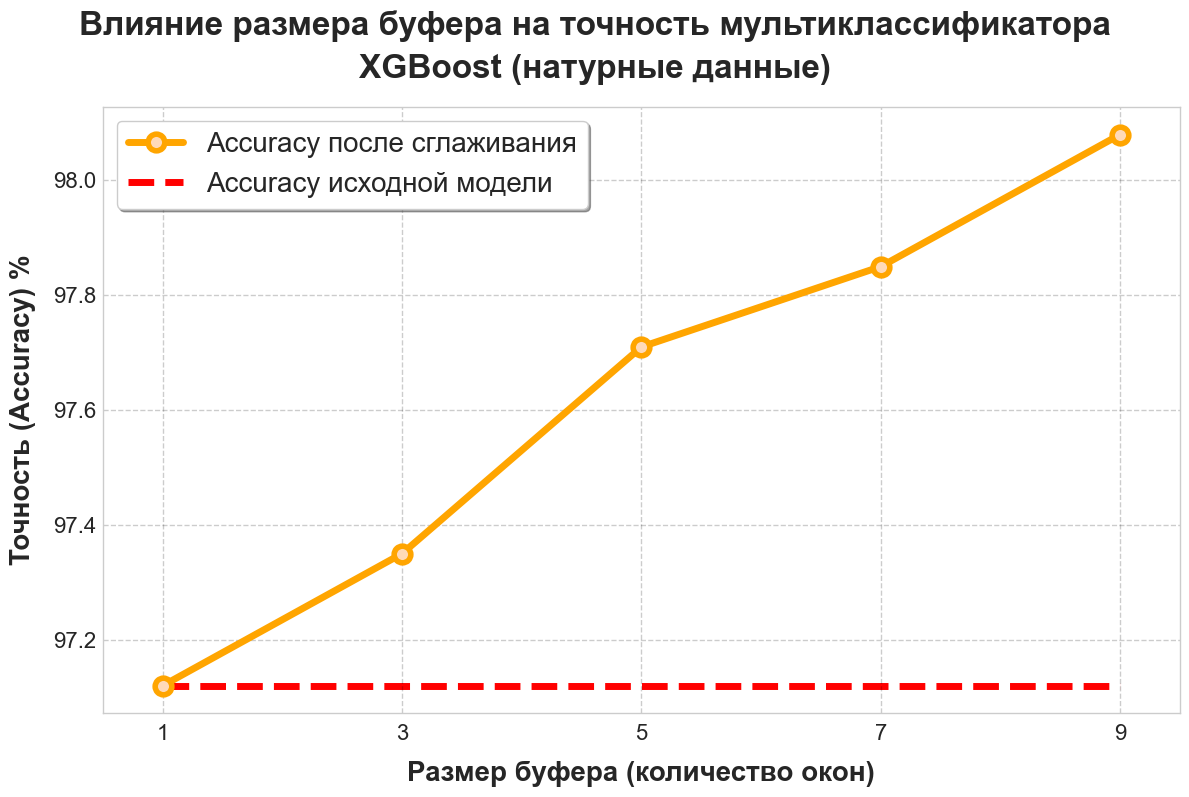

In [125]:
# Тестируем разные размеры буфера сглаживания
n = 9
buffer_sizes = [i for i in range(1, n + 1, 2)]
smoothing_results = []

for size in buffer_sizes:
    y_pred_smoothed = apply_rolling_predictions(y_pred_raw, window_size=size)
    acc = accuracy_score(y_test, y_pred_smoothed) * 100
    smoothing_results.append({"Buffer_Size": size, "Accuracy": acc})

smoothing_results = [{'Buffer_Size': 1, 'Accuracy': 97.12},
                     {'Buffer_Size': 3, 'Accuracy': 97.35},
                     {'Buffer_Size': 5, 'Accuracy': 97.71},
                     {'Buffer_Size': 7, 'Accuracy': 97.85},
                     {'Buffer_Size': 9, 'Accuracy': 98.08}]

df_smooth = pd.DataFrame(smoothing_results)
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df_smooth["Buffer_Size"], df_smooth["Accuracy"], marker='o', ms=12,
        linewidth=5, mec='orange', color='orange',
         mfc='peachpuff', label='Accuracy после сглаживания', mew=4)

x_positions = buffer_sizes
x_labels = [str(i) for i in buffer_sizes]

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12)

ax.grid(alpha=0.2, linestyle='--', linewidth=1, color='black')

# Отступы для меток
ax.tick_params(axis='x', pad=8, labelsize=16)
ax.tick_params(axis='y', pad=5, labelsize=16)

# Настройка подписей и заголовка
fig.suptitle('Влияние размера буфера на точность мультиклассификатора\nXGBoost (натурные данные)', 
             fontsize=24, fontweight='bold', y=0.99, linespacing=1.5)
ax.set_xlabel('Размер буфера (количество окон)', 
              fontsize=20, fontweight='bold', labelpad=12)
ax.set_ylabel('Точность (Accuracy) %', 
              fontsize=20, fontweight='bold', labelpad=12)

# Добавляем небольшие отступы по краям для лучшего вида
ax.set_xlim(0.5, buffer_sizes[-1] + 0.5)

# Строим графики
xlim = ax.get_xlim()  # получаем текущие пределы оси X
x_start, x_end = 1, n
xmin = (x_start - xlim[0]) / (xlim[1] - xlim[0])
xmax = (x_end - xlim[0]) / (xlim[1] - xlim[0])

ax.axhline(y=smoothing_results[0]['Accuracy'], color='red', 
           linestyle='--', label='Accuracy исходной модели', 
           linewidth=5, xmin=xmin, xmax=xmax, zorder=0)

# Настройка легенды
# ax.set_yticks([i/1000 for i in range(99010, 99026, 5)])

plt.legend(fontsize=20, 
           shadow=True, 
           loc='upper left',
           framealpha=1,
           frameon=True)

plt.tight_layout()
plt.savefig('APPLICATIONS/multi_buff_xgb_50features.png', dpi=600)
plt.show()